# Session 3 — Sentence-Level Analysis
## Measure 4: Clause Density / Subordination

Long sentences are not always complex, sometimes they are just lists. Clause density (how many finite verbs or subordinating markers per sentence) is another proxy for complexity.

**What is a clause?**
A clause is a unit of grammar containing a subject and a predicate (verb). There are two main types:
- **Independent clause**: Can stand alone as a complete sentence (e.g., "Alice fell down the rabbit hole")
- **Subordinate clause**: Cannot stand alone and depends on the main clause (e.g., "when she saw the White Rabbit")

**Why measure clause density?**
- **Syntactic complexity**: More subordinate clauses = more complex sentence structure
- **Cognitive load**: Sentences with multiple embedded clauses are harder to process
- **Writing maturity**: Advanced writers tend to use more subordination to express nuanced relationships between ideas
- **Genre differences**: Academic writing typically has higher clause density than fiction

**How we measure it:**
We count subordinating conjunctions and relative pronouns (that, which, who, when, where, because, although, if, while, etc.) as proxies for subordinate clauses. Each marker typically introduces a dependent clause that adds information to the main clause.

This notebook:
- splits into sentences
- counts clause-like elements using regex for conjunctions (that, which, because, when, if, while, etc.)
- computes clauses per sentence

We'll analyze Lewis Carroll's two Alice books to compare their syntactic complexity.

In [16]:
import re

# Load the Alice books from Project Gutenberg
def load_book(filepath):
    """Load and clean book text from Project Gutenberg"""
    with open(filepath, 'r', encoding='utf-8') as f:
        text = f.read()
    
    # Remove Project Gutenberg headers/footers
    if 'CHAPTER I' in text:
        start = text.find('CHAPTER I')
        text = text[start:]
    elif '*** START OF' in text:
        start = text.find('*** START OF')
        text = text[start + 100:]
    
    if '*** END OF' in text:
        end = text.find('*** END OF')
        text = text[:end]
    elif 'End of Project Gutenberg' in text:
        end = text.find('End of Project Gutenberg')
        text = text[:end]
    
    return text.strip()

# Load both books
CP_text = load_book('../data/Crime-punishment.txt')
BK_text = load_book('../data/The-Brotherskaramazov.txt')

print(f"Crime and punsihemt loaded: {len(CP_text):,} characters")
print(f"The Brotherskaramazov loaded: {len(BK_text):,} characters")

Crime and punsihemt loaded: 1,224,428 characters
The Brotherskaramazov loaded: 1,956,237 characters


In [ ]:
# Define clause markers (subordinating conjunctions and relative pronouns)
clause_markers = r'\b(that|which|who|whom|whose|where|when|while|if|because|although|though|unless|until|since|before|after|as)\b'

def analyze_clause_density(text, book_name, show_examples=5):
    """Analyze clause density in the text"""
    # Split into sentences
    sentences = re.split(r'[.!?]+\s+', text.strip())
    sentences = [s.strip() for s in sentences if s.strip() and len(s.split()) > 2]
    
    clause_counts = []
    clause_densities = []
    
    for s in sentences:
        # Count clause markers (each marker typically introduces a subordinate clause)
        num_markers = len(re.findall(clause_markers, s, flags=re.IGNORECASE))
        # Base clause + subordinate clauses
        clauses = 1 + num_markers
        tokens = len(s.split())
        density = clauses / (tokens / 10) if tokens > 0 else 0
        
        clause_counts.append(clauses)
        clause_densities.append(density)
    
    avg_clauses = sum(clause_counts) / len(clause_counts)
    avg_density = sum(clause_densities) / len(clause_densities)
    
    print(f"\n{'='*70}")
    print(f"{book_name}")
    print(f"{'='*70}")
    print(f"Total sentences analyzed: {len(sentences):,}")
    print(f"Average clauses per sentence: {avg_clauses:.2f}")
    print(f"Average clause density (clauses per 10 tokens): {avg_density:.2f}")
    
    # Show examples of complex sentences
    print(f"\nTop {show_examples} most complex sentences (by clause count):")
    print("-" * 70)
    
    # Sort sentences by clause count
    sentence_data = list(zip(sentences, clause_counts, [len(s.split()) for s in sentences]))
    sentence_data.sort(key=lambda x: x[1], reverse=True)
    
    for i, (sent, clauses, tokens) in enumerate(sentence_data[:show_examples], 1):
        # Truncate long sentences
        display_sent = sent if len(sent) < 150 else sent[:147] + "..."
        print(f"\n{i}. {display_sent}")
        print(f"   Tokens: {tokens}, Clauses: {clauses}, Density: {clauses/(tokens/10):.2f}")
    
    return clause_counts, clause_densities

# Analyze both books
CP_counts, CP_densities = analyze_clause_density(CP_text, "Alice's Adventures in Wonderland")
BK_counts, BK_densities = analyze_clause_density(BK_text, "Through the Looking-Glass")


Alice's Adventures in Wonderland
Total sentences analyzed: 12,802
Average clauses per sentence: 1.62
Average clause density (clauses per 10 tokens): 1.36

Top 5 most complex sentences (by clause count):
----------------------------------------------------------------------

1. Sonia flushed crimson, and Katerina
Ivanovna suddenly burst into tears, immediately
observing that she was “nervous and silly, that she
was too muc...
   Tokens: 271, Clauses: 24, Density: 0.89

2. Amalia Ivanovna turned as red as a lobster and
squealed that perhaps Katerina Ivanovna never had a
father, “but she had a vater aus Berlin and that...
   Tokens: 109, Clauses: 13, Density: 1.19

3. As for what you’ve alluded to in my let-
ter, be so good as to point out one word of falsehood,
show, that is, that you didn’t throw away your mone...
   Tokens: 93, Clauses: 11, Density: 1.18

4. At this Amalia Ivanovna, lashed to fury, struck
the table with her fist, and shrieked that she was
Amalia Ivanovna, and not Ludw

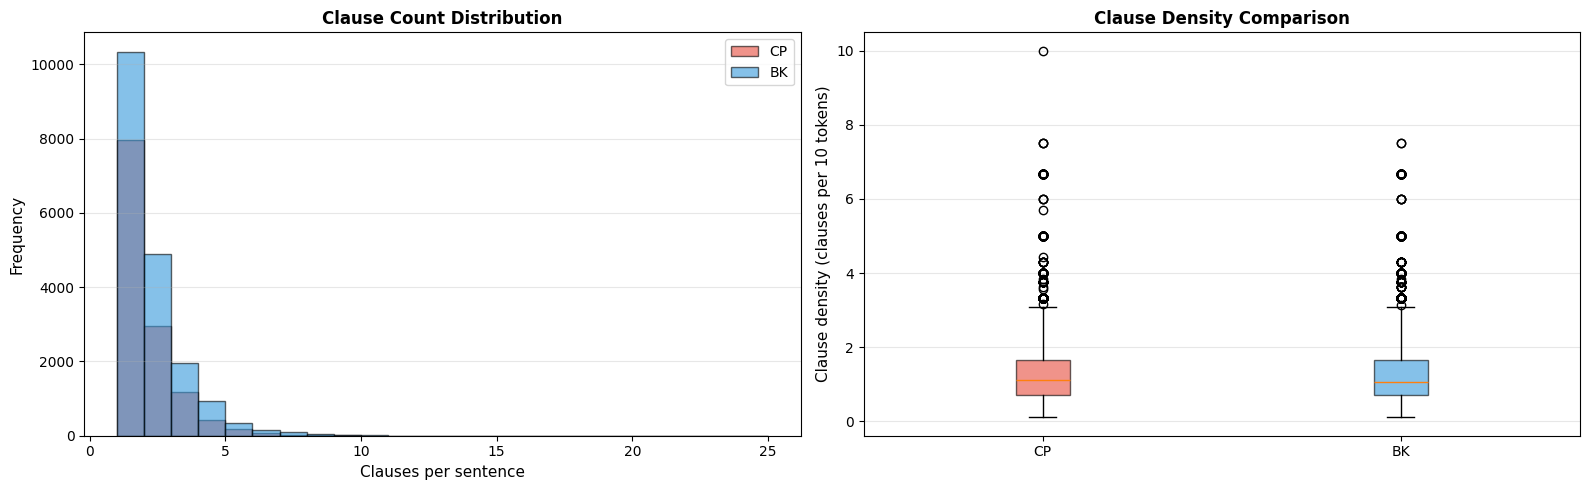


STATISTICAL COMPARISON
Metric                              Crime and punishmemt Brothers Karamazov
----------------------------------------------------------------------
Avg clauses per sentence                       1.62            1.79
Avg clause density                             1.36            1.28
Max clauses in one sentence                      24              14
Sentences with 3+ clauses                      1882            3549


In [ ]:
# Visualize clause density comparison
# Ensure matplotlib and numpy are installed, then import pyplot
# Install missing packages in the notebook environment if necessary

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of clause counts
ax1 = axes[0]
ax1.hist(CP_counts, bins=range(1, max(max(CP_counts), max(BK_counts))+2), 
         alpha=0.6, color='#e74c3c', label='CP', edgecolor='black')
ax1.hist(BK_counts, bins=range(1, max(max(CP_counts), max(BK_counts))+2), 
         alpha=0.6, color='#3498db', label='BK', edgecolor='black')
ax1.set_xlabel('Clauses per sentence', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Clause Count Distribution', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Box plot comparison
ax2 = axes[1]
box_data = [CP_densities, BK_densities]
bp = ax2.boxplot(box_data, tick_labels=['CP', 'BK'], patch_artist=True)
bp['boxes'][0].set_facecolor('#e74c3c')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#3498db')
bp['boxes'][1].set_alpha(0.6)
ax2.set_ylabel('Clause density (clauses per 10 tokens)', fontsize=11)
ax2.set_title('Clause Density Comparison', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Statistical summary
print("\n" + "="*70)
print("STATISTICAL COMPARISON")
print("="*70)
print(f"{'Metric':<35} {'Crime and punishmemt':>15} {'Brothers Karamazov':>15}")
print("-"*70)
print(f"{'Avg clauses per sentence':<35} {np.mean(CP_counts):>15.2f} {np.mean(BK_counts):>15.2f}")
print(f"{'Avg clause density':<35} {np.mean(CP_densities):>15.2f} {np.mean(BK_densities):>15.2f}")
print(f"{'Max clauses in one sentence':<35} {max(CP_counts):>15} {max(BK_counts):>15}")
print(f"{'Sentences with 3+ clauses':<35} {sum(1 for c in CP_counts if c >= 3):>15} {sum(1 for c in BK_counts if c >= 3):>15}") 
